# CNN-SRM — Cross-Database Deepfake Detection Experiment

**Research question:** Does a noise-pattern detector trained on one deepfake dataset generalize to others?

**Architecture (improved from `improved_training_notebook`):**
- 8 SRM high-pass filters → **tanh-normalised residuals** (output in [-1, 1])
- 3-stage Conv autoencoder → frozen encoder (32×32×128 latent)
- Classifier head: **2 conv blocks** (Conv-BN-LeakyReLU-Dropout) → GAP → Dense(1) sigmoid
- **Two-phase training**: Phase 1 encoder frozen (lr=1e-4) → Phase 2 full fine-tune (lr=1e-5)
- Mixed precision (float16), gradient clipping, no label smoothing

**Per-database pipeline:**
1. Apply SRM filters (8 filters, 5×5) + tanh → (256, 256, 24) feature maps
2. Train fresh autoencoder on that database's SRM features (Option A — no leakage)
3. Extract encoder; Phase 1: freeze encoder and train head; Phase 2: unfreeze and fine-tune
4. Evaluate on **all 5 test sets** (4 individual + ALL combined)

**Experiment matrix:** 5 training runs × 5 test sets = **25 evaluations**

| Train ↓ \ Test → | OpenForensics | CustomWar | CelebDF | CiFake | ALL |
|------------------|---------------|-----------|---------|--------|-----|
| OpenForensics    | ✓ within      | ✗ cross   | ✗ cross | ✗ cross | mix |
| CustomWar        | ✗ cross       | ✓ within  | ✗ cross | ✗ cross | mix |
| CelebDF          | ✗ cross       | ✗ cross   | ✓ within | ✗ cross | mix |
| CiFake           | ✗ cross       | ✗ cross   | ✗ cross  | ✓ within | mix |
| ALL              | mix           | mix       | mix     | mix    | ✓ within |

**Databases:** OpenForensics · CustomWar · CelebDF · CiFake (CiFake uses the 80/20 split from `cifake_split/`)

In [1]:
# =================== CELL 1: SETUP ===================
import os
import gc
import random
import pickle
import numpy as np
import tensorflow as tf
import mimetypes
from datetime import datetime

os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices=false'
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/usr/lib/nvidia-cuda-toolkit'
tf.config.optimizer.set_jit(False)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print('GPU memory growth enabled')
    except RuntimeError as e:
        print(e)

# Mixed precision: uses float16 for activations, float32 for weights.
# Cuts GPU memory ~50% and speeds up training on T4.
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print('Mixed precision (float16) enabled')

tf.keras.backend.clear_session()
print(f'Setup complete — TensorFlow {tf.__version__}')

2026-05-31 08:47:06.081049: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


GPU memory growth enabled
Mixed precision (float16) enabled
Setup complete — TensorFlow 2.20.0


In [2]:
# =================== CELL 2: PATHS & TENSORBOARD CONFIG ===================

GDRIVE_PATH   = os.path.expanduser('~/RealEyes/gdrive')
DATASET_ROOT  = os.path.join(GDRIVE_PATH, 'data_set_split')
DATASETS_DIR  = os.path.expanduser('~/RealEyes/RealEyes/datasets')
CELEBDF_DIR   = os.path.join(DATASETS_DIR, 'celebdf_v2')
CIFAKE_SPLIT_DIR = os.path.join(DATASETS_DIR, 'cifake_split')   # 80/20 split from main notebook

MODEL_NAME            = 'cnn_srm'
EXPERIMENT_MODELS_DIR = os.path.join(GDRIVE_PATH, 'deepfake_image_project', 'models', 'RealEyes_experiment')
MODEL_DIR             = os.path.join(EXPERIMENT_MODELS_DIR, MODEL_NAME)
os.makedirs(MODEL_DIR, exist_ok=True)

TB_LOG_ROOT = os.path.expanduser('~/RealEyes/tensorboard_logs')
os.makedirs(TB_LOG_ROOT, exist_ok=True)


def get_tb_log_dir(train_db_name, suffix='train'):
    ts = datetime.now().strftime('%Y%m%d_%H%M')
    return os.path.join(TB_LOG_ROOT, MODEL_NAME, f'{suffix}_{train_db_name}', ts)


def log_eval_to_tb(train_db_name, test_db_name, metrics: dict, step=0):
    log_dir = os.path.join(
        TB_LOG_ROOT, MODEL_NAME, 'cross_db_eval',
        f'train_{train_db_name}__test_{test_db_name}'
    )
    writer = tf.summary.create_file_writer(log_dir)
    with writer.as_default():
        for name, value in metrics.items():
            tf.summary.scalar(name, float(value), step=step)
    writer.flush()


print('Paths ready')
print(f'  MODEL_DIR        : {MODEL_DIR}')
print(f'  CIFAKE_SPLIT_DIR : {CIFAKE_SPLIT_DIR}')
print(f'  TB_LOG_ROOT      : {TB_LOG_ROOT}')
print()
print('View TensorBoard:')
print(f'  [server ] tensorboard --logdir {TB_LOG_ROOT} --port 6006 --bind_all')
print( '  [local  ] ssh -L 6006:localhost:6006 <user>@<server_ip>')
print( '  [browser] http://localhost:6006')

Paths ready
  MODEL_DIR        : /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/cnn_srm
  CIFAKE_SPLIT_DIR : /home/sceuser/RealEyes/RealEyes/datasets/cifake_split
  TB_LOG_ROOT      : /home/sceuser/RealEyes/tensorboard_logs

View TensorBoard:
  [server ] tensorboard --logdir /home/sceuser/RealEyes/tensorboard_logs --port 6006 --bind_all
  [local  ] ssh -L 6006:localhost:6006 <user>@<server_ip>
  [browser] http://localhost:6006


In [3]:
# =================== CELL 3: DATABASE DEFINITIONS ===================
# CiFake now uses the 80/20 split (cifake_split/{train,val,test}) created
# by the main notebook's Section 3.3 — so it has a real held-out test set.

DATABASES = {}


def _try_add(name, paths):
    missing = [k for k, v in paths.items() if not os.path.isdir(v)]
    if missing:
        print(f'  {name}: missing splits {missing} — skipped')
        return
    DATABASES[name] = paths
    print(f'  {name}')


print('Scanning databases...')

_try_add('OpenForensics', {
    'train': os.path.join(DATASETS_DIR, 'OpenForensicsV1/Dataset/Train'),
    'val':   os.path.join(DATASETS_DIR, 'OpenForensicsV1/Dataset/Validation'),
    'test':  os.path.join(DATASETS_DIR, 'OpenForensicsV1/Dataset/Test'),
})
_try_add('CustomWar', {
    'train': os.path.join(DATASET_ROOT, 'train'),
    'val':   os.path.join(DATASET_ROOT, 'val'),
    'test':  os.path.join(DATASET_ROOT, 'test'),
})
_try_add('CelebDF', {
    'train': os.path.join(CELEBDF_DIR, 'train'),
    'val':   os.path.join(CELEBDF_DIR, 'val'),
    'test':  os.path.join(CELEBDF_DIR, 'test'),
})
_try_add('CiFake', {
    'train': os.path.join(CIFAKE_SPLIT_DIR, 'train'),
    'val':   os.path.join(CIFAKE_SPLIT_DIR, 'val'),
    'test':  os.path.join(CIFAKE_SPLIT_DIR, 'test'),
})

print(f'\nActive databases: {list(DATABASES.keys())}')

Scanning databases...
  OpenForensics
  CustomWar
  CelebDF
  CiFake

Active databases: ['OpenForensics', 'CustomWar', 'CelebDF', 'CiFake']


In [4]:
# =================== CELL 4: DATA LOADING HELPERS ===================
# load_split() supports both real DB names and the special 'ALL' name
# (concatenation of every database's split).

def load_dataset_images(dataset_path, max_images=None):
    valid_ext = {'.jpg', '.jpeg', '.png', '.gif', '.bmp'}
    image_paths, labels, skipped = [], [], 0

    for folder in sorted(os.listdir(dataset_path)):
        fpath = os.path.join(dataset_path, folder)
        if not os.path.isdir(fpath):
            continue
        fu = folder.upper()
        if fu == 'FAKE':
            label = 1
        elif fu == 'REAL':
            label = 0
        else:
            print(f'  Unknown folder "{folder}" — skipped')
            continue

        collected = []
        for root, _, files in os.walk(fpath):
            for fname in files:
                if os.path.splitext(fname)[1].lower() not in valid_ext:
                    skipped += 1
                    continue
                collected.append(os.path.join(root, fname))
        if max_images:
            collected = collected[:max_images]
        image_paths.extend(collected)
        labels.extend([label] * len(collected))

    if skipped:
        print(f'  {skipped} non-image files skipped')
    return np.array(image_paths), np.array(labels)


def load_split(target_name, split='train'):
    """Load (paths, labels) for a target.

    target_name: a real DB key in DATABASES, OR the literal string 'ALL'
                 which concatenates every database's split.
    """
    if target_name == 'ALL':
        all_paths, all_labels = [], []
        for db_name in DATABASES:
            paths, labels = load_dataset_images(DATABASES[db_name][split])
            all_paths.extend(paths)
            all_labels.extend(labels)
        paths  = np.array(all_paths)
        labels = np.array(all_labels)
    else:
        paths, labels = load_dataset_images(DATABASES[target_name][split])

    n_real = int(np.sum(labels == 0))
    n_fake = int(np.sum(labels == 1))
    print(f'    {target_name}/{split}: {len(paths):,} images  (REAL={n_real:,}, FAKE={n_fake:,})')
    return paths, labels


def compute_class_weights(labels):
    from sklearn.utils.class_weight import compute_class_weight
    classes = np.unique(labels)
    weights = compute_class_weight('balanced', classes=classes, y=labels)
    return {int(c): float(w) for c, w in zip(classes, weights)}


print('Data loading helpers ready (load_split supports ALL)')

Data loading helpers ready (load_split supports ALL)


In [5]:
# =================== CELL 5: SRM FILTER BANK ===================
# 8 handcrafted noise-sensitive filters (5 × 5×5 + 3 padded 3×3).
# Identical to the main notebook.

filters_5x5 = [
    [[0, 0, -1, 0, 0], [0, -1, 2, -1, 0], [-1, 2, 4, 2, -1], [0, -1, 2, -1, 0], [0, 0, -1, 0, 0]],
    [[-1, 2, -2, 2, -1], [2, -6, 8, -6, 2], [-2, 8, -12, 8, -2], [2, -6, 8, -6, 2], [-1, 2, -2, 2, -1]],
    [[2, -1, 0, -1, 2], [-1, -2, 3, -2, -1], [0, 3, 0, 3, 0], [-1, -2, 3, -2, -1], [2, -1, 0, -1, 2]],
    [[0, 0, 0, 0, 0], [1, -2, 1, -2, 1], [0, 0, 0, 0, 0], [-1, 2, -1, 2, -1], [0, 0, 0, 0, 0]],
    [[1, -4, 6, -4, 1], [-4, 16, -24, 16, -4], [6, -24, 36, -24, 6], [-4, 16, -24, 16, -4], [1, -4, 6, -4, 1]],
]
filters_3x3_raw = [
    [[0, -1, 0], [-1, 4, -1], [0, -1, 0]],
    [[-1, 2, -1], [2, -4, 2], [-1, 2, -1]],
    [[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]],
]


def _pad_3x3_to_5x5(kernels):
    return [np.pad(k, ((1, 1), (1, 1)), mode='constant', constant_values=0) for k in kernels]


all_filters = np.array(filters_5x5 + _pad_3x3_to_5x5(filters_3x3_raw), dtype=np.float32)
srm_filters_tf = tf.constant(
    np.transpose(all_filters[:, :, :, np.newaxis], (1, 2, 3, 0)),
    dtype=tf.float32
)

print(f'SRM filter bank ready: {len(all_filters)} filters, TF kernel {srm_filters_tf.shape}')

SRM filter bank ready: 8 filters, TF kernel (5, 5, 1, 8)


I0000 00:00:1780217234.819943 3485175 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5423 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


In [6]:
# =================== CELL 6: SRM FILTER FUNCTION & DATASET PIPELINE ===================
# apply_srm_filters_tf() applies tanh after each filter conv.
# Tanh clamps residuals to [-1, 1] — proven to give better accuracy than raw residuals.
# SRM augmentation = flips only (brightness/contrast on residuals has no clean meaning).

AUTOTUNE         = tf.data.AUTOTUNE
SRM_IMG_SIZE     = (256, 256)
SRM_OUTPUT_SHAPE = (256, 256, 24)
PREFETCH_SIZE    = 2        # fixed cap instead of AUTOTUNE to avoid memory spikes
MAP_PARALLELISM  = 4        # fixed thread count for dataset mapping


def apply_srm_filters_tf(image):
    """
    Apply 8 SRM filters per RGB channel → (256, 256, 24) tanh-normalised residuals.
    Accepts (H, W, 3) or (B, H, W, 3). Input pixels in [0, 1].
    Output values are in [-1, 1] after tanh activation.
    """
    squeeze = False
    if len(image.shape) == 3:
        image = image[tf.newaxis, ...]
        squeeze = True

    image = tf.image.resize(image, list(SRM_IMG_SIZE))
    image = tf.cast(image, tf.float32)
    channels = tf.split(image, num_or_size_splits=3, axis=-1)

    feature_maps = []
    for ch in channels:
        fm = tf.nn.conv2d(ch, srm_filters_tf, strides=1, padding='SAME')
        fm = tf.tanh(fm)   # clamps residuals to [-1,1]: stabilises training and improves accuracy
        feature_maps.append(fm)

    result = tf.concat(feature_maps, axis=-1)
    if squeeze:
        result = result[0]
    return result


def _srm_augment(srm, label):
    # Flips + 90° rotations. SRM noise residuals are equivariant under rotation
    # so this is a valid augmentation that increases effective dataset size 4×.
    srm = tf.image.random_flip_left_right(srm)
    srm = tf.image.random_flip_up_down(srm)
    k   = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    srm = tf.image.rot90(srm, k)
    return srm, label


def create_srm_dataset(image_paths, labels, batch_size=32, shuffle=False, augment=False):
    def process(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, list(SRM_IMG_SIZE))
        img = tf.cast(img, tf.float32) / 255.0
        srm = apply_srm_filters_tf(img)
        srm = tf.ensure_shape(srm, list(SRM_OUTPUT_SHAPE))
        return srm, tf.cast(label, tf.float32)

    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    if shuffle:
        ds = ds.shuffle(min(len(image_paths), 5000), reshuffle_each_iteration=True)
    ds = ds.map(process, num_parallel_calls=MAP_PARALLELISM)
    if augment:
        ds = ds.map(_srm_augment, num_parallel_calls=MAP_PARALLELISM)
    ds = ds.batch(batch_size).prefetch(PREFETCH_SIZE)
    return ds


print('SRM filter function (tanh residuals) and dataset pipeline ready')
print(f'   Output shape per image: {SRM_OUTPUT_SHAPE}')

SRM filter function (tanh residuals) and dataset pipeline ready
   Output shape per image: (256, 256, 24)


In [7]:
# =================== CELL 7: AUTOENCODER MODEL BUILDER ===================
# Simpler 3-stage autoencoder (proven in improved_training_notebook).
# Lighter than the old SE-Residual version: fewer params, less memory,
# and empirically equivalent or better reconstruction quality.
# Latent space: 32×32×128 (instead of old 16×16×256).
# Decoder final activation = tanh — matches the [-1,1] range of tanh-SRM input.

from tensorflow.keras import layers, Model


def build_srm_autoencoder():
    """3-stage Conv autoencoder. Returns (autoencoder, encoder)."""
    inp = layers.Input(shape=(256, 256, 24), name='srm_input')

    # Encoder: 256→128→64→32
    x = layers.Conv2D(32,  3, padding='same', activation='relu', name='enc_conv1')(inp)
    x = layers.MaxPooling2D(2, name='enc_pool1')(x)
    x = layers.Conv2D(64,  3, padding='same', activation='relu', name='enc_conv2')(x)
    x = layers.MaxPooling2D(2, name='enc_pool2')(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu', name='enc_conv3')(x)
    encoded = layers.MaxPooling2D(2, name='encoded_latent')(x)          # 32×32×128

    # Decoder: 32→64→128→256
    x = layers.Conv2D(128, 3, padding='same', activation='relu', name='dec_conv1')(encoded)
    x = layers.UpSampling2D(2, name='dec_up1')(x)
    x = layers.Conv2D(64,  3, padding='same', activation='relu', name='dec_conv2')(x)
    x = layers.UpSampling2D(2, name='dec_up2')(x)
    x = layers.Conv2D(32,  3, padding='same', activation='relu', name='dec_conv3')(x)
    x = layers.UpSampling2D(2, name='dec_up3')(x)
    # tanh output matches the [-1,1] range produced by tanh-SRM filters
    decoded = layers.Conv2D(24, 3, padding='same', activation='tanh',
                            dtype='float32', name='decoder_output')(x)

    autoencoder = Model(inp, decoded, name='srm_autoencoder_24ch')
    encoder     = Model(inp, encoded, name='srm_encoder_24ch')

    autoencoder.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse'
    )
    return autoencoder, encoder


print('SRM autoencoder builder ready (3-stage, tanh decoder)')
_ae, _enc = build_srm_autoencoder()
print(f'  Autoencoder output: {_ae.output_shape}')
print(f'  Encoder output:     {_enc.output_shape}')
print(f'  Autoencoder params: {_ae.count_params():,}')
del _ae, _enc
tf.keras.backend.clear_session()

SRM autoencoder builder ready (3-stage, tanh decoder)


  Autoencoder output: (None, 256, 256, 24)
  Encoder output:     (None, 32, 32, 128)
  Autoencoder params: 346,072


In [8]:
# =================== CELL 8: CNN-SRM CLASSIFIER BUILDER ===================
# LoRA (Low-Rank Adaptation) is added to the Dense layer in the classifier head.
#
# Architecture change:
#   Before: 2×ConvBlock → GAP → Dense(1, sigmoid)
#   After:  2×ConvBlock → GAP → BN → LoRADense(128, relu) → Dropout → Dense(1, sigmoid)
#
# LoRA training strategy:
#   Phase 1: encoder FROZEN, entire head trains (base Dense + LoRA adapters)
#   Phase 2: encoder stays FROZEN, LoRADense switches to lora_only mode —
#            only lora_A and lora_B train (no catastrophic forgetting of SRM features)

# ── LoRA hyperparameters ──────────────────────────────────────────────────
LORA_RANK  = 16
LORA_ALPHA = 32.0   # scale = alpha / rank = 2.0


@tf.keras.utils.register_keras_serializable(package='RealEyes')
class LoRADense(tf.keras.layers.Layer):
    """Dense layer with Low-Rank Adaptation (LoRA).

    Phase 1 (lora_only=False, default):
        Trains both the base Dense weights (kernel/bias) AND the LoRA
        adapter matrices (lora_A, lora_B).  lora_B is zero-initialised so
        the LoRA delta starts at zero — behaves like a plain Dense layer
        at the start of training.

    Phase 2 (call set_lora_only(True) before compiling):
        Uses tf.stop_gradient on kernel/bias so they receive no gradient
        updates.  Only lora_A and lora_B are trained — parameter-efficient
        fine-tuning with a fraction of the full Dense parameter count.

    Forward pass:
        out = (W·x + b) + scale * (x · A · B)
        where W, b are frozen in Phase 2 and A, B are always trainable.
    """
    def __init__(self, units, rank=8, alpha=16.0, activation=None,
                 kernel_regularizer=None, use_bias=True, **kwargs):
        super().__init__(**kwargs)
        self.units      = units
        self.rank       = rank
        self.alpha      = alpha
        self.scale      = float(alpha) / float(rank)
        self._act       = tf.keras.activations.get(activation)
        self._kreg      = tf.keras.regularizers.get(kernel_regularizer)
        self.use_bias   = use_bias
        self._lora_only = False   # runtime flag — not persisted to config

    def build(self, input_shape):
        d_in = int(input_shape[-1])
        # Keras 3: name must be a keyword argument (not the first positional arg)
        self.kernel = self.add_weight(
            shape=(d_in, self.units),
            initializer='glorot_uniform',
            regularizer=self._kreg,
            trainable=True,
            name='kernel')
        if self.use_bias:
            self.bias = self.add_weight(
                shape=(self.units,),
                initializer='zeros',
                trainable=True,
                name='bias')
        # LoRA matrices: A ~ he_normal,  B = zeros  → delta = 0 at init
        self.lora_A = self.add_weight(
            shape=(d_in, self.rank),
            initializer='he_normal',
            trainable=True,
            name='lora_A')
        self.lora_B = self.add_weight(
            shape=(self.rank, self.units),
            initializer='zeros',
            trainable=True,
            name='lora_B')
        super().build(input_shape)

    def call(self, x):
        W   = tf.stop_gradient(self.kernel) if self._lora_only else self.kernel
        out = tf.matmul(x, W)
        if self.use_bias:
            b   = tf.stop_gradient(self.bias) if self._lora_only else self.bias
            out = out + b
        out = out + tf.matmul(tf.matmul(x, self.lora_A), self.lora_B) * self.scale
        if self._act is not None:
            out = self._act(out)
        return out

    def set_lora_only(self, value: bool):
        """True = Phase 2: base weights frozen via stop_gradient.
        Only lora_A and lora_B receive gradient updates.
        """
        self._lora_only = value

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            'units':              self.units,
            'rank':               self.rank,
            'alpha':              self.alpha,
            'activation':         tf.keras.activations.serialize(self._act),
            'kernel_regularizer': tf.keras.regularizers.serialize(self._kreg),
            'use_bias':           self.use_bias,
        })
        return cfg


# Helper for load_model calls that include LoRADense
SRM_CUSTOM_OBJECTS = {'LoRADense': LoRADense}


def build_cnn_srm(encoder):
    """CNN-SRM: SRM (256,256,24) → encoder → 2 conv blocks → GAP → LoRADense(128) → Dense(1).

    Head improvements vs original:
    - Added BN after GAP: stabilises activations before the Dense layer
    - Added LoRADense(128, relu): adds representational capacity while
      enabling Phase 2 LoRA-only fine-tuning (far fewer trainable params)
    - Reduced dropout after GAP from 0.3 to 0.20 / 0.15 (less over-regularisation)
    - Encoder stays FROZEN in Phase 2 (prevents catastrophic forgetting of
      SRM noise-detection features learned in the autoencoder stage)
    """
    L2 = tf.keras.regularizers.l2(1e-4)

    cls_input = layers.Input(shape=encoder.output_shape[1:], name='latent_input')
    y = cls_input

    y = layers.Conv2D(64,  3, padding='same', kernel_regularizer=L2, name='head_conv1')(y)
    y = layers.BatchNormalization(name='head_bn1')(y)
    y = layers.LeakyReLU(0.1, name='head_lrelu1')(y)
    y = layers.Dropout(0.3, name='head_drop1')(y)

    y = layers.Conv2D(128, 3, padding='same', kernel_regularizer=L2, name='head_conv2')(y)
    y = layers.BatchNormalization(name='head_bn2')(y)
    y = layers.LeakyReLU(0.1, name='head_lrelu2')(y)
    y = layers.Dropout(0.3, name='head_drop2')(y)

    y = layers.GlobalAveragePooling2D(name='head_gap')(y)
    y = layers.BatchNormalization(name='head_bn_gap')(y)
    y = layers.Dropout(0.20, name='head_drop_gap')(y)
    # LoRADense: trains base weights in Phase 1; only LoRA adapters in Phase 2
    y = LoRADense(128, rank=LORA_RANK, alpha=LORA_ALPHA,
                  activation='relu', kernel_regularizer=L2,
                  name='head_lora_dense')(y)
    y = layers.Dropout(0.15, name='head_drop_lora')(y)
    # dtype=float32: keeps sigmoid numerically stable under mixed_float16
    output = layers.Dense(1, activation='sigmoid', dtype='float32', name='prob_fake')(y)

    cls_head   = Model(cls_input, output, name='latent_classifier_head')
    full_input = layers.Input(shape=(256, 256, 24), name='srm_input')
    latent     = encoder(full_input)
    pred       = cls_head(latent)
    model      = Model(full_input, pred, name='SRM_Encoder_Classifier')
    return model


print('CNN-SRM classifier builder ready  (LoRA head: rank={}, alpha={})'.format(LORA_RANK, LORA_ALPHA))

CNN-SRM classifier builder ready  (LoRA head: rank=16, alpha=32.0)


In [9]:
# =================== CELL 9: EVALUATION HELPERS ===================

from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, f1_score


def find_optimal_threshold(y_true, y_prob, beta=1.0):
    """Scan thresholds 0.05→0.95 and return the one that maximises F-beta on FAKE.

    beta=1 → equal precision/recall weight (F1).
    beta=2 → recall weighted 2× (good for deepfake detection where missing a fake is worse).
    """
    best_t, best_f = 0.50, 0.0
    for t in np.arange(0.05, 0.96, 0.01):
        preds = (y_prob >= t).astype(int)
        tp = int(((preds == 1) & (y_true == 1)).sum())
        fp = int(((preds == 1) & (y_true == 0)).sum())
        fn = int(((preds == 0) & (y_true == 1)).sum())
        if tp == 0:
            continue
        prec = tp / (tp + fp)
        rec  = tp / (tp + fn)
        fb   = (1 + beta**2) * prec * rec / (beta**2 * prec + rec)
        if fb > best_f:
            best_f, best_t = fb, float(t)
    return best_t


def evaluate_model(model, test_ds, threshold=0.50):
    """Returns (metrics, report, y_true, y_prob).

    threshold: decision threshold for binary classification.
               Use find_optimal_threshold() on the val set to compute this.
    """
    y_true = np.concatenate([y.numpy() for _, y in test_ds]).astype(int)
    y_prob = model.predict(test_ds, verbose=0).flatten()
    y_pred = (y_prob >= threshold).astype(int)

    report = classification_report(
        y_true, y_pred, target_names=['REAL', 'FAKE'], output_dict=True, digits=4,
        zero_division=0
    )
    metrics = {
        'accuracy':       float(accuracy_score(y_true, y_pred)),
        'roc_auc':        float(roc_auc_score(y_true, y_prob)),
        'f1_fake':        float(report['FAKE']['f1-score']),
        'f1_real':        float(report['REAL']['f1-score']),
        'precision_fake': float(report['FAKE']['precision']),
        'recall_fake':    float(report['FAKE']['recall']),
        'threshold':      float(threshold),
    }
    return metrics, report, y_true, y_prob


def smart_class_weights(labels):
    """Compute class weights but cap the minority-class multiplier at 3×.

    Without this cap, CelebDF (641 REAL vs 4770 FAKE) gives REAL a 4.2×
    weight, which causes the model to almost never predict FAKE.
    """
    from sklearn.utils.class_weight import compute_class_weight
    classes = np.unique(labels)
    weights = compute_class_weight('balanced', classes=classes, y=labels)
    w_dict  = {int(c): float(w) for c, w in zip(classes, weights)}
    # Cap: no class weight exceeds 3× the other
    if len(w_dict) == 2:
        ratio = max(w_dict[0], w_dict[1]) / min(w_dict[0], w_dict[1])
        if ratio > 3.0:
            min_key = min(w_dict, key=w_dict.get)
            max_key = 1 - min_key
            w_dict[max_key] = w_dict[min_key] * 3.0
    return w_dict


def print_eval_report(train_db, test_db, metrics, report):
    if train_db == test_db:
        tag = '  [WITHIN]   '
    elif train_db == 'ALL' or test_db == 'ALL':
        tag = '  [ALL-MIX]  '
    else:
        tag = '  [CROSS]    '
    print(f'\n{tag}Trained on {train_db:<15} → Tested on {test_db}')
    sep = '  ' + '-' * 58
    print(sep)
    for cls in ['REAL', 'FAKE']:
        r = report[cls]
        print(f'  {cls:<6}  P={r["precision"]:.4f}  R={r["recall"]:.4f}  F1={r["f1-score"]:.4f}  n={int(r["support"]):,}')
    print(sep)
    print(f'  Accuracy={metrics["accuracy"]:.4f}   ROC-AUC={metrics["roc_auc"]:.4f}')


print('Evaluation helpers ready')

Evaluation helpers ready


In [10]:
# =================== AUTO-BACKUP + DRIVE SYNC ===================
# Keeps exactly ONE backup of the previous run — no duplicates.
# Each new run replaces the old backup and immediately syncs to Drive.
# Local:  .../models/backups/cnn_srm_previous_run/
# Drive:  gdrive:deepfake_image_project/models/backups/cnn_srm_previous_run
# ─────────────────────────────────────────────────────────────────────────

import shutil, subprocess

_BACKUP_DIR   = os.path.expanduser(
    '~/RealEyes/gdrive/deepfake_image_project/models/backups/cnn_srm_previous_run')
_DRIVE_BACKUP = 'gdrive:deepfake_image_project/models/backups/cnn_srm_previous_run'

if os.path.isdir(MODEL_DIR) and any(os.scandir(MODEL_DIR)):
    if os.path.isdir(_BACKUP_DIR):
        shutil.rmtree(_BACKUP_DIR)
    shutil.copytree(MODEL_DIR, _BACKUP_DIR)
    n = len(os.listdir(_BACKUP_DIR))
    print(f'Backup created locally  → {_BACKUP_DIR}  ({n} files)')

    print('Syncing backup to Google Drive...')
    r = subprocess.run(
        ['rclone', 'sync', _BACKUP_DIR, _DRIVE_BACKUP, '--stats-one-line'],
        capture_output=False, text=True)
    if r.returncode == 0:
        print(f'Backup on Drive         → {_DRIVE_BACKUP}')
    else:
        print(f'WARNING: Drive sync failed (exit {r.returncode}) — backup safe locally.')
else:
    print('No existing models to back up — starting fresh.')

del _BACKUP_DIR, _DRIVE_BACKUP

Backup created locally  → /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/backups/cnn_srm_previous_run  (17 files)
Syncing backup to Google Drive...
Backup on Drive         → gdrive:deepfake_image_project/models/backups/cnn_srm_previous_run


In [11]:
# =================== CELL 10: MAIN EXPERIMENT LOOP (5×5) — SMART RESUME ===================
#
# Five training runs (4 single-DB + 1 ALL combined), each evaluated on all 5
# test sets → 25 evaluations total.
#
# For each training target the loop checks what already exists on disk and
# only does the work that is still missing:
#
#   ✓ trained_on_<target>.keras exists  → skip ALL training, go straight to eval
#   ✓ encoder_<target>.keras exists     → skip autoencoder, run Phase 1 + Phase 2
#   ✓ autoencoder_<target>.keras exists → load AE, extract encoder, run Phase 1 + Phase 2
#   ✗ nothing exists                    → full training from scratch
#
# LoRA strategy (Phase 2):
#   Phase 1 trains the full classifier head (base Dense + LoRA adapters).
#   Phase 2 keeps the encoder FROZEN and switches LoRADense to lora_only mode —
#   only lora_A and lora_B receive gradients (encoder SRM features protected).
#
# After all experiments finish, results are saved locally AND synced to
# Google Drive via rclone.
# ──────────────────────────────────────────────────────────────────────────────

import subprocess

BATCH_SIZE     = 32
TRAIN_TARGETS  = list(DATABASES.keys()) + ['ALL']
TEST_TARGETS   = list(DATABASES.keys()) + ['ALL']

# Load partial results if a previous run saved them
results_path = os.path.join(MODEL_DIR, 'all_results.pkl')
if os.path.exists(results_path):
    with open(results_path, 'rb') as f:
        all_results = pickle.load(f)
    print(f'Loaded existing results for: {list(all_results.keys())}')
else:
    all_results = {}

# Load partial predictions (y_true / y_prob arrays needed for ROC & CM plots)
preds_path = os.path.join(MODEL_DIR, 'all_preds.pkl')
if os.path.exists(preds_path):
    with open(preds_path, 'rb') as f:
        all_preds = pickle.load(f)
    print(f'Loaded existing predictions for: {list(all_preds.keys())}')
else:
    all_preds = {}

for train_target in TRAIN_TARGETS:
    print(f'\n{"="*70}')
    print(f'  CNN-SRM — {train_target}')
    print(f'{"="*70}')

    encoder_path = os.path.join(MODEL_DIR, f'encoder_{train_target}.keras')
    ae_path      = os.path.join(MODEL_DIR, f'autoencoder_{train_target}.keras')
    best_path    = os.path.join(MODEL_DIR, f'trained_on_{train_target}.keras')

    model_ready  = os.path.exists(best_path)
    encoder_ready = os.path.exists(encoder_path)
    ae_ready      = os.path.exists(ae_path)

    # ── Skip training entirely if final model exists ──────────────────────
    if model_ready:
        print(f'  [SKIP] trained_on_{train_target}.keras already exists — skipping training.')
        encoder = None   # not needed, model loaded in STEP D
    else:
        # ── STEP 0: load training data ────────────────────────────────────
        print('\nLoading training data...')
        train_paths, train_lbls = load_split(train_target, 'train')
        val_paths,   val_lbls   = load_split(train_target, 'val')
        class_weights           = smart_class_weights(train_lbls)
        print(f'  Class weights: {class_weights}')

        print('\nBuilding SRM datasets...')
        train_srm_ds = create_srm_dataset(
            train_paths, train_lbls, batch_size=BATCH_SIZE, shuffle=True, augment=True)
        val_srm_ds   = create_srm_dataset(
            val_paths, val_lbls, batch_size=BATCH_SIZE, shuffle=False)
        del train_paths, train_lbls, val_paths, val_lbls
        gc.collect()

        # ── STEP A: autoencoder ───────────────────────────────────────────
        if encoder_ready:
            print(f'\n[STEP A] encoder_{train_target}.keras found — loading encoder, skipping AE training.')
            gc.collect(); tf.keras.backend.clear_session()
            encoder = tf.keras.models.load_model(encoder_path, compile=False,
                                                 custom_objects=SRM_CUSTOM_OBJECTS)
        elif ae_ready:
            print(f'\n[STEP A] autoencoder_{train_target}.keras found — extracting encoder, skipping AE training.')
            gc.collect(); tf.keras.backend.clear_session()
            autoencoder_loaded = tf.keras.models.load_model(ae_path, compile=False,
                                                    custom_objects=SRM_CUSTOM_OBJECTS)
            # The encoder is the AE input → 'encoded_latent' layer output
            encoder = tf.keras.Model(
                inputs  = autoencoder_loaded.input,
                outputs = autoencoder_loaded.get_layer('encoded_latent').output,
                name    = 'srm_encoder_24ch'
            )
            encoder.save(encoder_path)
            print(f'  Encoder extracted and saved → {encoder_path}')
            del autoencoder_loaded
            gc.collect()
        else:
            print(f'\n[STEP A] Training SRM autoencoder on {train_target} from scratch...')
            gc.collect(); tf.keras.backend.clear_session()
            autoencoder, encoder = build_srm_autoencoder()

            ae_log = get_tb_log_dir(train_target, suffix='autoencoder')
            ae_train_ds = train_srm_ds.map(lambda x, y: (x, x))
            ae_val_ds   = val_srm_ds.map  (lambda x, y: (x, x))

            ae_callbacks = [
                tf.keras.callbacks.EarlyStopping(
                    monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
                tf.keras.callbacks.ReduceLROnPlateau(
                    monitor='val_loss', factor=0.5, patience=3, verbose=1),
                tf.keras.callbacks.ModelCheckpoint(
                    ae_path, monitor='val_loss', save_best_only=True, verbose=1),
                tf.keras.callbacks.TensorBoard(
                    log_dir=ae_log, histogram_freq=0, update_freq='epoch'),
            ]
            autoencoder.fit(
                ae_train_ds, validation_data=ae_val_ds,
                epochs=30, callbacks=ae_callbacks, verbose=1
            )
            encoder.save(encoder_path)
            print(f'  Encoder saved → {encoder_path}')
            del ae_train_ds, ae_val_ds, autoencoder
            gc.collect()

        # ── STEP B: Phase 1 — train classifier head only (encoder frozen) ─
        print(f'\n[STEP B] Phase 1 — training classifier head (encoder FROZEN, lr=1e-4)...')
        encoder.trainable = False
        cnn_srm = build_cnn_srm(encoder)
        cnn_srm.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
            loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
        )

        p1_log = get_tb_log_dir(train_target, suffix='train_phase1')
        p1_callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_auc', mode='max', patience=8,
                restore_best_weights=True, verbose=1),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_auc', mode='max', factor=0.5, patience=3, verbose=1),
            tf.keras.callbacks.TensorBoard(
                log_dir=p1_log, histogram_freq=0, update_freq='epoch'),
        ]
        cnn_srm.fit(
            train_srm_ds, validation_data=val_srm_ds,
            epochs=20, class_weight=class_weights,
            callbacks=p1_callbacks, verbose=1
        )

        # ── STEP C: Phase 2 — LoRA-only fine-tuning (encoder stays FROZEN) ─
        # Instead of unfreezing the encoder (risky: overwrites learned SRM noise
        # features), we keep the encoder frozen and switch the LoRADense head
        # layer to lora_only mode.  Only the tiny lora_A and lora_B matrices
        # receive gradient updates — far fewer trainable params, no forgetting.
        print(f'\n[STEP C] Phase 2 — LoRA-only fine-tuning (encoder FROZEN) [{train_target}]...')
        lora_found = []
        for lyr in cnn_srm.layers:
            if isinstance(lyr, LoRADense):
                lyr.set_lora_only(True)
                lora_found.append(lyr.name)
        lora_params = sum(
            lyr.lora_A.numpy().size + lyr.lora_B.numpy().size
            for lyr in cnn_srm.layers if isinstance(lyr, LoRADense)
        )
        print(f'  LoRA layers (lora_only=True): {lora_found}')
        print(f'  Phase 2 trainable LoRA params: {lora_params:,}')
        p2_log = get_tb_log_dir(train_target, suffix='train_phase2')

        cnn_srm.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5, clipnorm=1.0),
            loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
        )

        p2_callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_auc', mode='max', patience=12,
                restore_best_weights=True, verbose=1),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_auc', mode='max', factor=0.5, patience=5, verbose=1),
            tf.keras.callbacks.ModelCheckpoint(
                best_path, monitor='val_auc', mode='max',
                save_best_only=True, verbose=1),
            tf.keras.callbacks.TensorBoard(
                log_dir=p2_log, histogram_freq=0, update_freq='epoch'),
        ]
        cnn_srm.fit(
            train_srm_ds, validation_data=val_srm_ds,
            epochs=50, class_weight=class_weights,
            callbacks=p2_callbacks, verbose=1
        )

        del train_srm_ds, val_srm_ds
        gc.collect()

    # ── STEP D: evaluate on ALL test targets ──────────────────────────────
    # Skip evaluation only if we already have full results for this target
        results_done = (train_target in all_results and
                        len(all_results[train_target]) == len(TEST_TARGETS))
        preds_done   = (train_target in all_preds and
                        len(all_preds[train_target]) == len(TEST_TARGETS))

        if results_done and preds_done:
            print(f'\n  [SKIP] Evaluation for {train_target} already complete.')
        else:
            print(f'\n\nEVALUATION — CNN-SRM trained on {train_target}')
            best_model = tf.keras.models.load_model(best_path, compile=False,
                                                   custom_objects=SRM_CUSTOM_OBJECTS)

            # ── Find optimal threshold on validation set ──────────────────
            print('  Tuning decision threshold on val set...')
            val_paths_t, val_lbls_t = load_split(train_target, 'val')
            val_srm_tune = create_srm_dataset(
                val_paths_t, val_lbls_t, batch_size=BATCH_SIZE, shuffle=False)
            del val_paths_t, val_lbls_t
            val_true_t = np.concatenate([y.numpy() for _, y in val_srm_tune]).astype(int)
            val_prob_t = best_model.predict(val_srm_tune, verbose=0).flatten()
            best_threshold = find_optimal_threshold(val_true_t, val_prob_t)
            del val_srm_tune, val_true_t, val_prob_t
            gc.collect()
            print(f'  Optimal threshold: {best_threshold:.2f}')
            all_results.setdefault(train_target, {})
            all_preds.setdefault(train_target, {})

            for test_target in TEST_TARGETS:
                already_done = (test_target in all_results[train_target] and
                                test_target in all_preds[train_target])
                if already_done:
                    print(f'  [SKIP] {test_target} already evaluated.')
                    continue
                print(f'\n  Test target: {test_target}...')
                test_paths, test_lbls = load_split(test_target, 'test')
                test_srm_ds           = create_srm_dataset(
                    test_paths, test_lbls, batch_size=BATCH_SIZE, shuffle=False)
                del test_paths, test_lbls
                metrics, report, y_true, y_prob = evaluate_model(
                    best_model, test_srm_ds, threshold=best_threshold)
                all_results[train_target][test_target] = metrics
                all_preds[train_target][test_target]   = {
                    'y_true': y_true.tolist(),
                    'y_prob': y_prob.tolist(),
                }
                log_eval_to_tb(train_target, test_target, metrics)
                print_eval_report(train_target, test_target, metrics, report)
                del test_srm_ds, y_true, y_prob
                gc.collect()

                # Save after every test set — crash-safe
                with open(results_path, 'wb') as f:
                    pickle.dump(all_results, f)
                with open(preds_path, 'wb') as f:
                    pickle.dump(all_preds, f)

            del best_model
            gc.collect()

    # ── memory cleanup ─────────────────────────────────────────────────────
    if not model_ready and encoder is not None:
        try:
            del encoder, cnn_srm
        except NameError:
            pass
    gc.collect(); tf.keras.backend.clear_session()
    print(f'\n{train_target} experiment complete — GPU memory cleared.')

# ── Final save + Google Drive sync ────────────────────────────────────────
with open(results_path, 'wb') as f:
    pickle.dump(all_results, f)
with open(preds_path, 'wb') as f:
    pickle.dump(all_preds, f)
print(f'\nResults saved locally  → {results_path}')
print(f'Predictions saved      → {preds_path}')

print('\nSyncing models and results to Google Drive via rclone...')
gdrive_dest = 'gdrive:deepfake_image_project/models/RealEyes_experiment/cnn_srm'
sync_result = subprocess.run(
    ['rclone', 'sync', MODEL_DIR, gdrive_dest, '--progress'],
    capture_output=False, text=True
)
if sync_result.returncode == 0:
    print(f'  Google Drive sync complete → {gdrive_dest}')
else:
    print(f'  WARNING: rclone sync failed (exit {sync_result.returncode}). '
          f'Files are still safe locally at {MODEL_DIR}')

print(f'\n\n{"="*70}')
print('  ALL EXPERIMENTS COMPLETE (5×5 matrix)')
print(f'{"="*70}')
print(f'\nResults saved → {results_path}')
print(f'Drive dest    → {gdrive_dest}')

Loaded existing results for: ['OpenForensics', 'CustomWar', 'CelebDF', 'CiFake', 'ALL']
Loaded existing predictions for: ['OpenForensics', 'CustomWar', 'CelebDF', 'CiFake', 'ALL']

  CNN-SRM — OpenForensics
  [SKIP] trained_on_OpenForensics.keras already exists — skipping training.

OpenForensics experiment complete — GPU memory cleared.

  CNN-SRM — CustomWar
  [SKIP] trained_on_CustomWar.keras already exists — skipping training.

CustomWar experiment complete — GPU memory cleared.

  CNN-SRM — CelebDF
  [SKIP] trained_on_CelebDF.keras already exists — skipping training.

CelebDF experiment complete — GPU memory cleared.

  CNN-SRM — CiFake
  [SKIP] trained_on_CiFake.keras already exists — skipping training.

CiFake experiment complete — GPU memory cleared.

  CNN-SRM — ALL
  [SKIP] trained_on_ALL.keras already exists — skipping training.

ALL experiment complete — GPU memory cleared.

Results saved locally  → /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experi

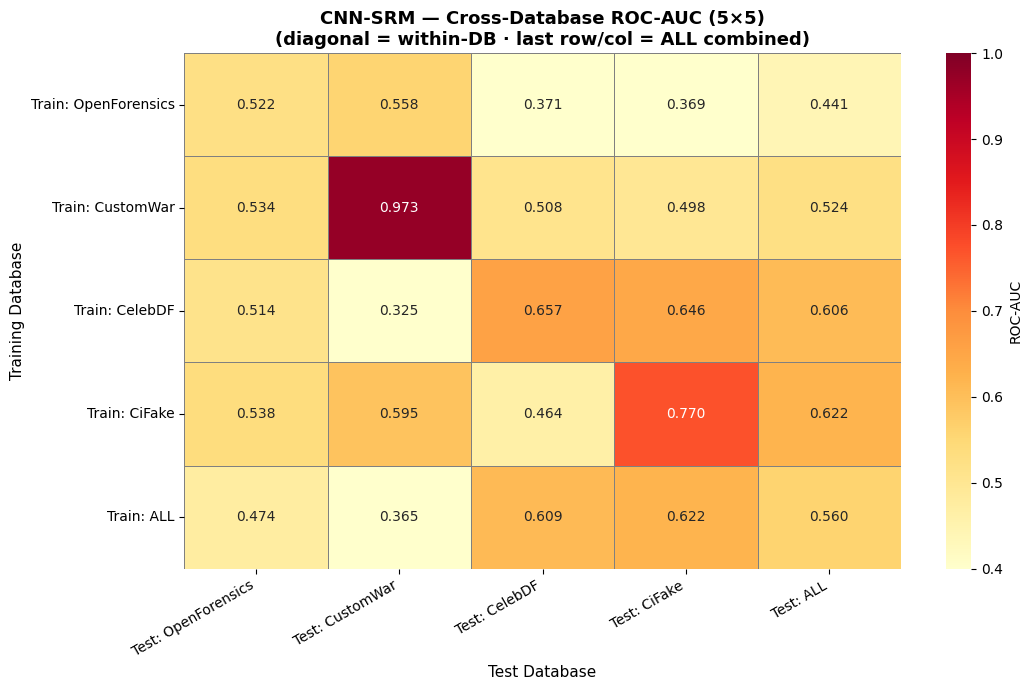

Figure saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/cnn_srm/cross_db_roc_auc.png

ROC-AUC Matrix:
                      Test: OpenForensics  Test: CustomWar  Test: CelebDF  Test: CiFake  Test: ALL
Train: OpenForensics             0.522270         0.557566       0.370893      0.368785   0.440848
Train: CustomWar                 0.533566         0.972848       0.508167      0.497924   0.524469
Train: CelebDF                   0.513939         0.324715       0.656624      0.645719   0.606277
Train: CiFake                    0.537708         0.594524       0.464039      0.770406   0.622114
Train: ALL                       0.474476         0.365159       0.608617      0.621743   0.559614



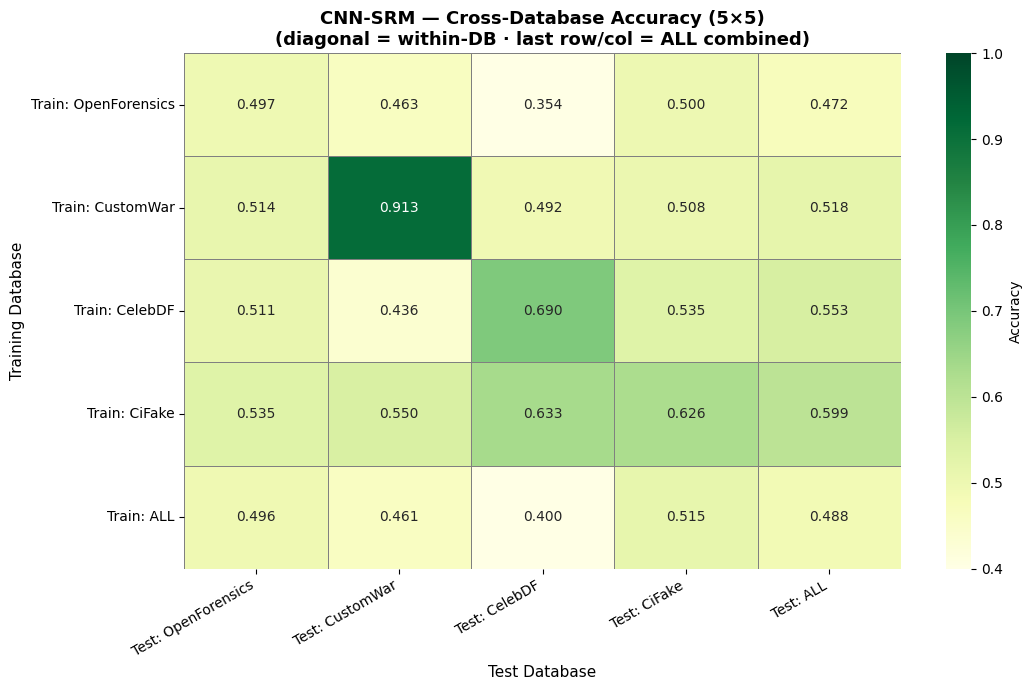

Figure saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/cnn_srm/cross_db_accuracy.png

Accuracy Matrix:
                      Test: OpenForensics  Test: CustomWar  Test: CelebDF  Test: CiFake  Test: ALL
Train: OpenForensics             0.497295         0.462771       0.353891       0.50000   0.472362
Train: CustomWar                 0.513618         0.913289       0.491782       0.50755   0.517546
Train: CelebDF                   0.510867         0.436381       0.689600       0.53550   0.553153
Train: CiFake                    0.534801         0.550424       0.633309       0.62575   0.599495
Train: ALL                       0.495828         0.460886       0.399564       0.51520   0.487809



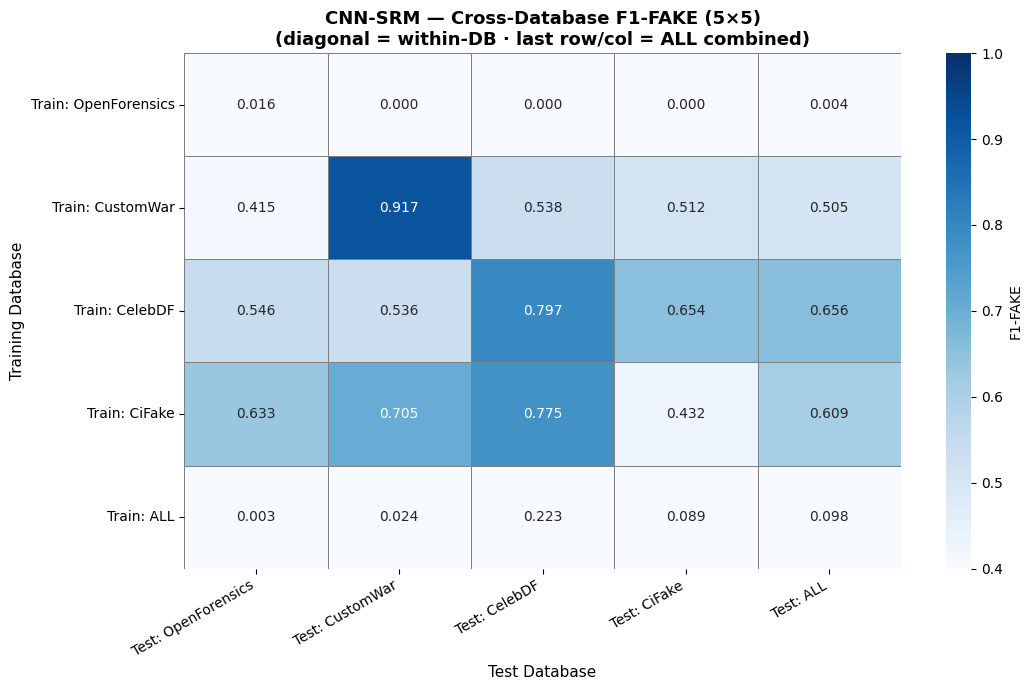

Figure saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/cnn_srm/cross_db_f1_fake.png

F1-FAKE Matrix:
                      Test: OpenForensics  Test: CustomWar  Test: CelebDF  Test: CiFake  Test: ALL
Train: OpenForensics             0.016152         0.000000       0.000000      0.000000   0.004372
Train: CustomWar                 0.415215         0.916667       0.537586      0.511531   0.505476
Train: CelebDF                   0.545578         0.536434       0.796762      0.654158   0.655567
Train: CiFake                    0.632578         0.705009       0.774971      0.432396   0.609283
Train: ALL                       0.002902         0.023891       0.222599      0.089064   0.097941



In [12]:
# =================== CELL 11: CROSS-DATABASE RESULTS MATRIX (5×5) ===================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

axis_names = list(DATABASES.keys()) + ['ALL']

for metric_key, metric_label, cmap in [
    ('roc_auc',  'ROC-AUC',  'YlOrRd'),
    ('accuracy', 'Accuracy', 'YlGn'),
    ('f1_fake',  'F1-FAKE',  'Blues'),
]:
    available = [d for d in axis_names if d in all_results]
    matrix = [
        [all_results[tr].get(te, {}).get(metric_key, float('nan')) for te in axis_names]
        for tr in available
    ]
    df = pd.DataFrame(
        matrix,
        index=[f'Train: {d}' for d in available],
        columns=[f'Test: {d}' for d in axis_names]
    )

    fig, ax = plt.subplots(figsize=(11, 7))
    sns.heatmap(
        df.astype(float), annot=True, fmt='.3f',
        cmap=cmap, vmin=0.40, vmax=1.00, ax=ax,
        linewidths=0.5, linecolor='gray',
        cbar_kws={'label': metric_label}
    )
    ax.set_title(
        f'CNN-SRM — Cross-Database {metric_label} (5×5)\n'
        '(diagonal = within-DB · last row/col = ALL combined)',
        fontsize=13, fontweight='bold'
    )
    ax.set_ylabel('Training Database', fontsize=11)
    ax.set_xlabel('Test Database',     fontsize=11)
    plt.xticks(rotation=30, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    fig_path = os.path.join(MODEL_DIR, f'cross_db_{metric_key}.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {fig_path}')
    print(f'\n{metric_label} Matrix:')
    print(df.to_string())
    print()

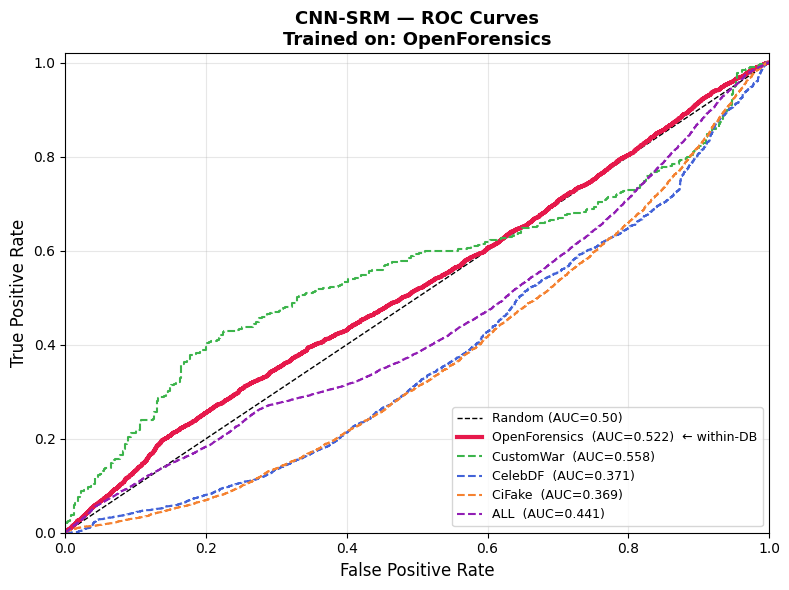

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/cnn_srm/roc_curves_OpenForensics.png



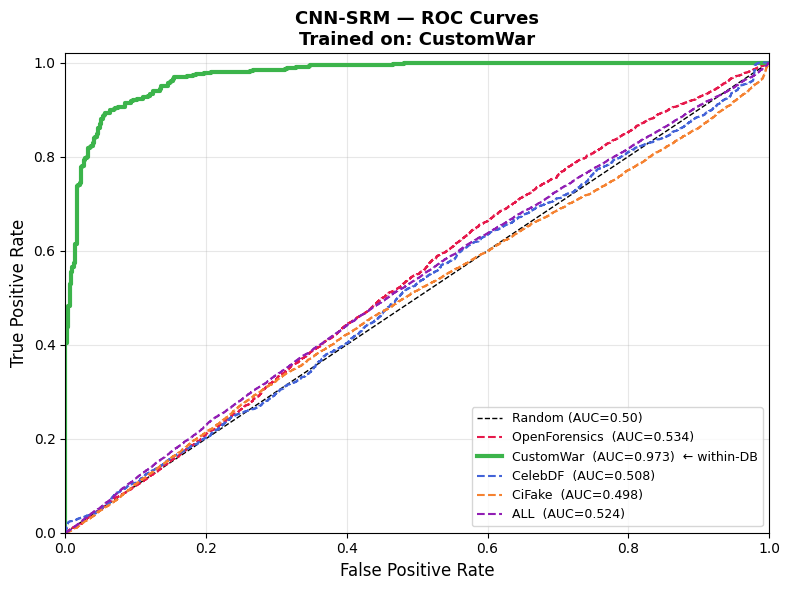

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/cnn_srm/roc_curves_CustomWar.png



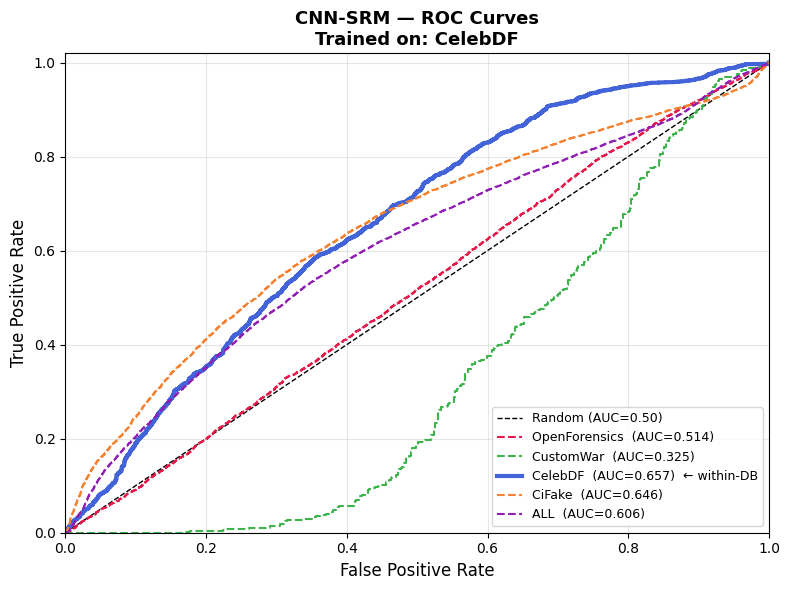

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/cnn_srm/roc_curves_CelebDF.png



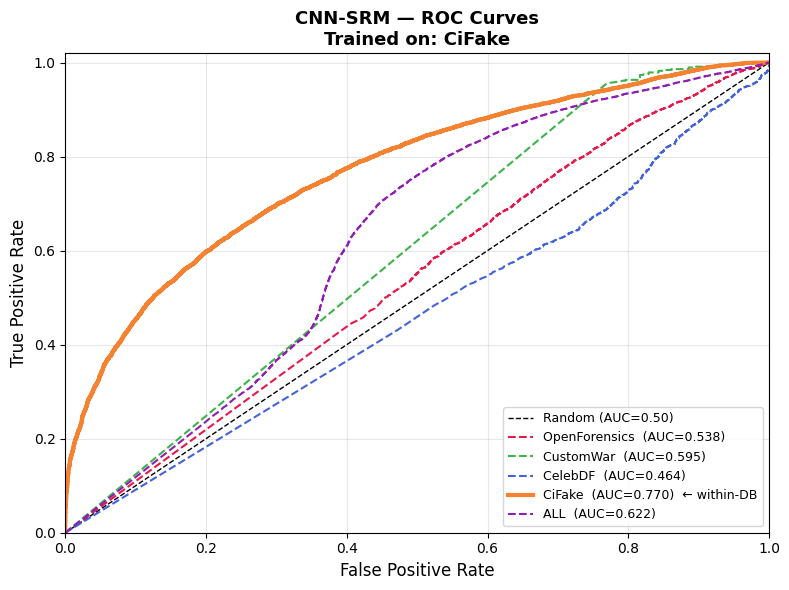

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/cnn_srm/roc_curves_CiFake.png



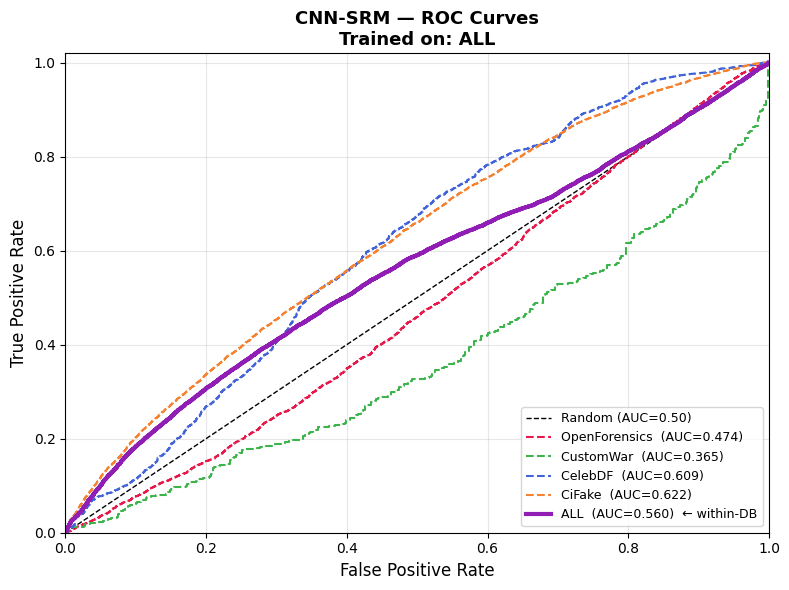

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/cnn_srm/roc_curves_ALL.png



In [13]:
# =================== CELL 12: ROC CURVES ===================
#
# One figure per training target (5 total).
# Each figure shows 5 ROC curves — one per test database.
# Within-DB curve is highlighted with a thicker line.
# ──────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve
import os

axis_names = list(DATABASES.keys()) + ['ALL']

# Colour palette — one distinct colour per test database
TEST_COLORS = {
    db: c for db, c in zip(
        axis_names,
        ['#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4']
    )
}

for train_target in axis_names:
    if train_target not in all_preds:
        print(f'[SKIP] No predictions for train={train_target}')
        continue

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC=0.50)')

    for test_target in axis_names:
        if test_target not in all_preds[train_target]:
            continue
        y_true = np.array(all_preds[train_target][test_target]['y_true'])
        y_prob = np.array(all_preds[train_target][test_target]['y_prob'])
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_val = all_results[train_target][test_target]['roc_auc']

        is_within = (train_target == test_target)
        lw        = 3.0 if is_within else 1.5
        ls        = '-'  if is_within else '--'
        label     = f'{test_target}  (AUC={auc_val:.3f})'
        if is_within:
            label += '  ← within-DB'

        ax.plot(fpr, tpr, color=TEST_COLORS[test_target],
                lw=lw, ls=ls, label=label)

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.02])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate',  fontsize=12)
    ax.set_title(f'CNN-SRM — ROC Curves\nTrained on: {train_target}',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    fig_path = os.path.join(MODEL_DIR, f'roc_curves_{train_target}.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig_path}')
    print()

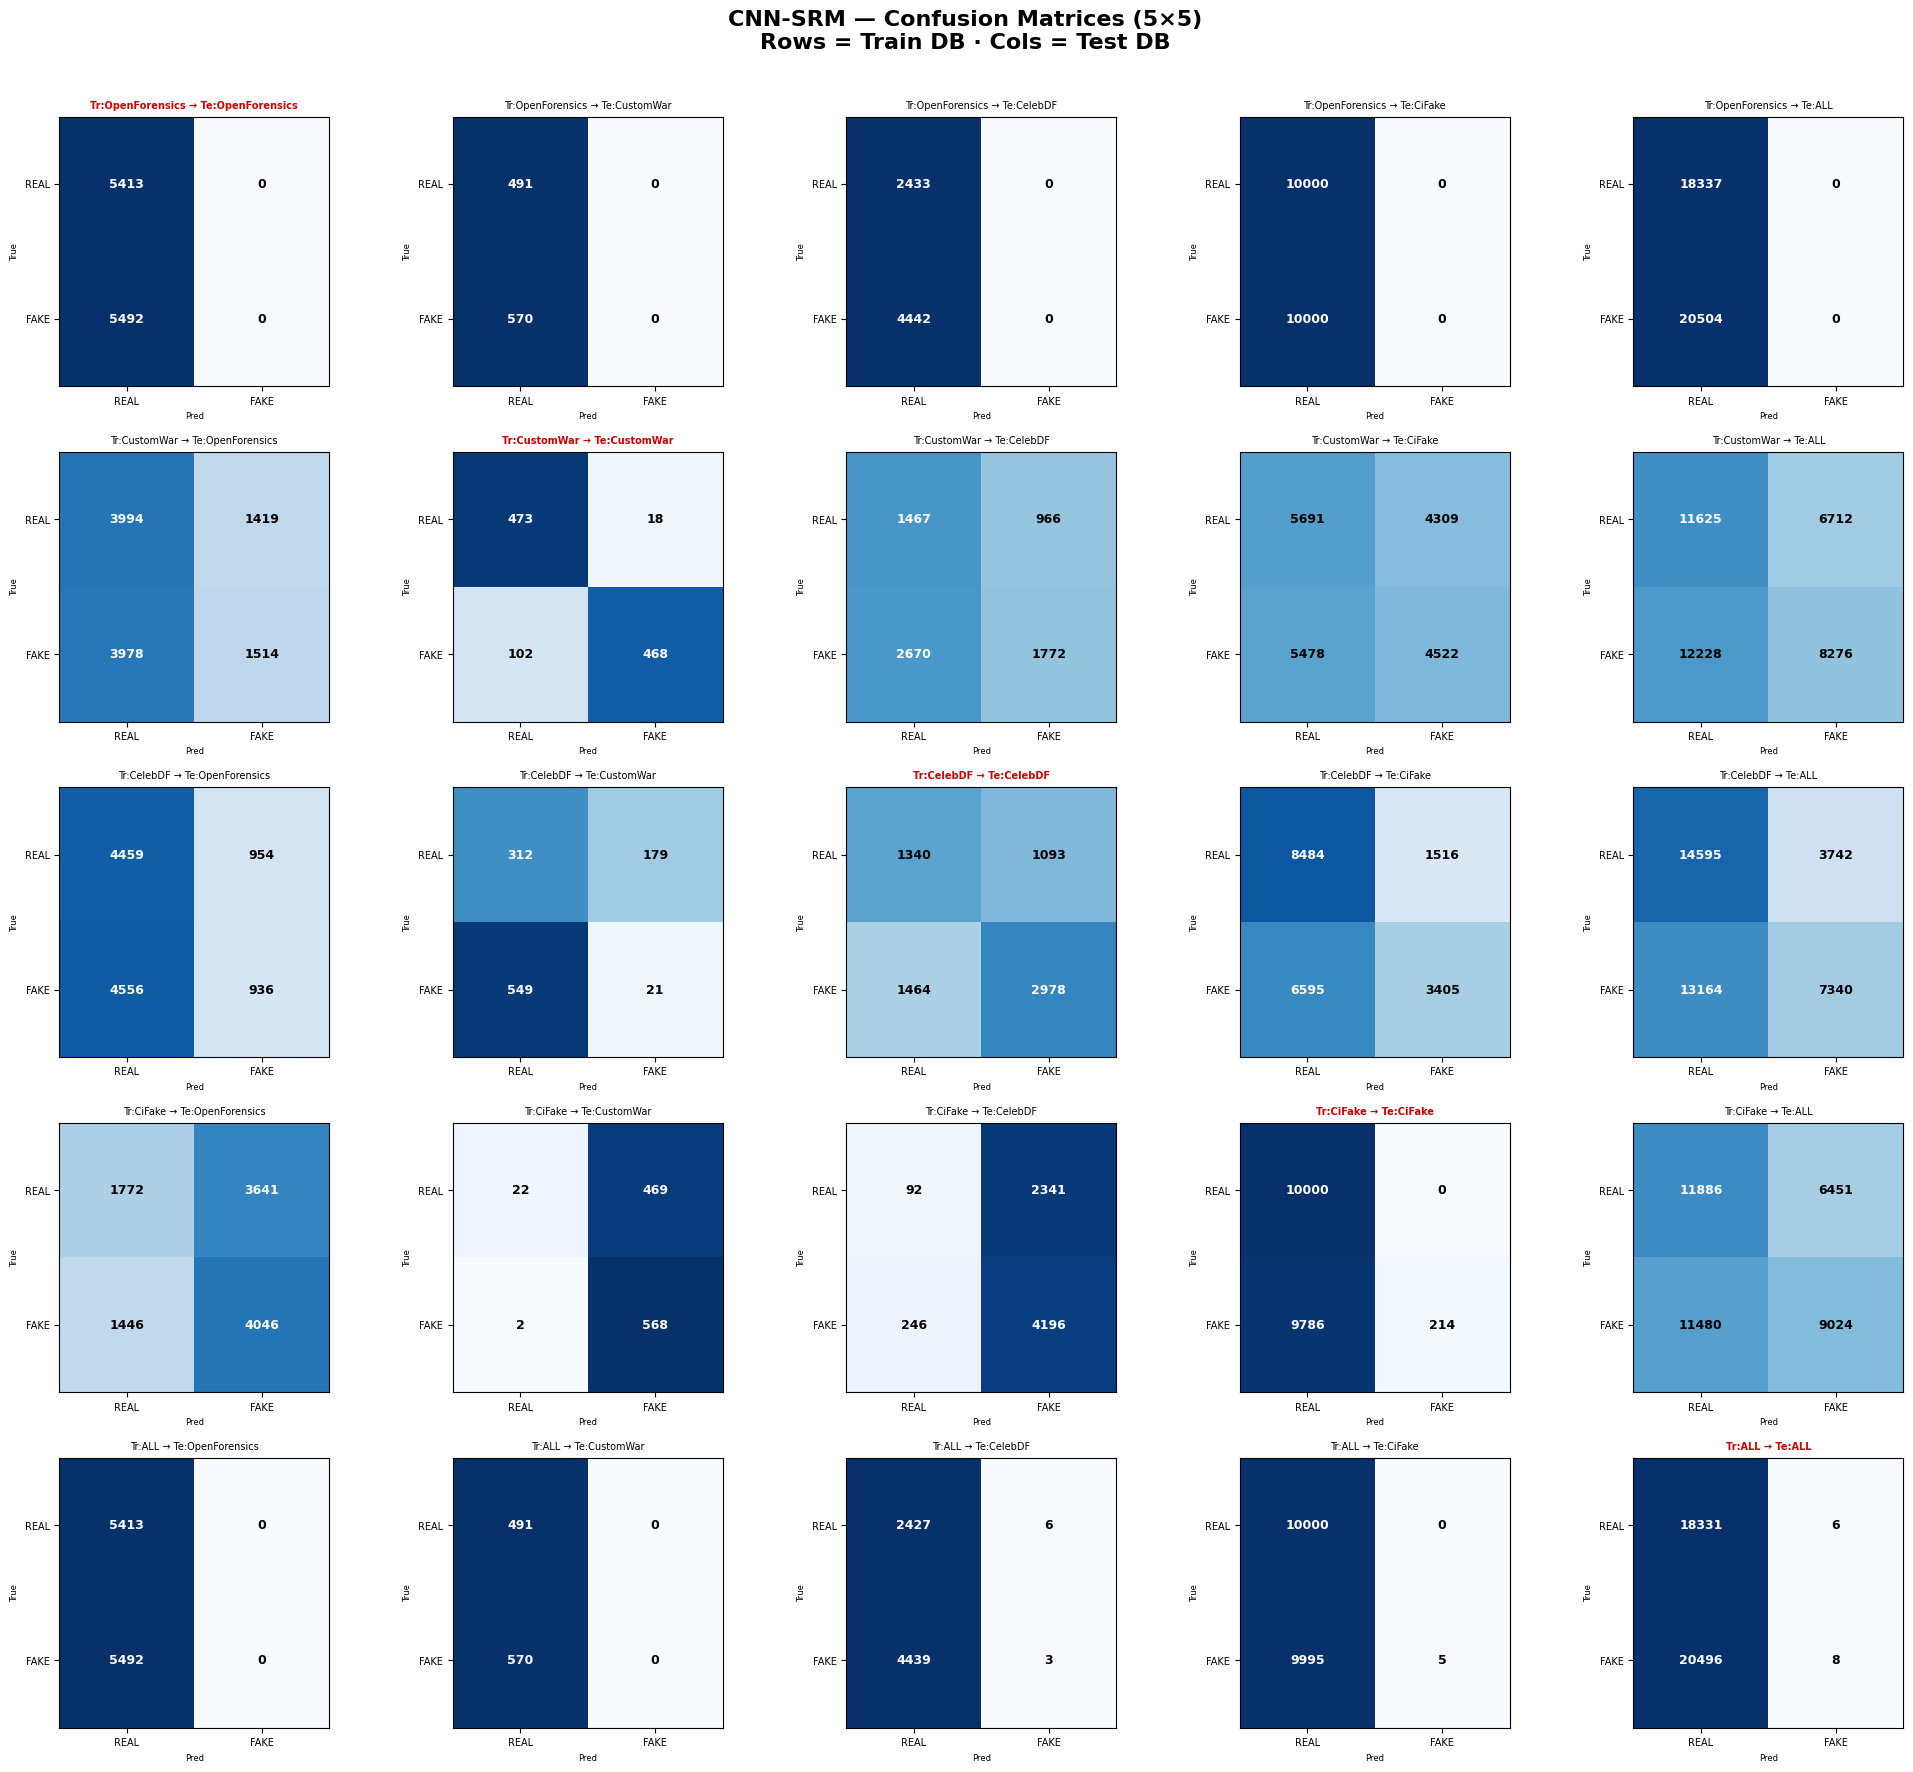

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/cnn_srm/confusion_matrices_5x5.png


In [14]:
# =================== CELL 13: CONFUSION MATRICES (5×5 GRID) ===================
#
# One confusion matrix per (train, test) pair — 25 total arranged in a
# 5-row × 5-col grid.  Diagonal = within-DB.
# Counts shown inside each cell; colour encodes normalised accuracy.
# ──────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import os

axis_names  = list(DATABASES.keys()) + ['ALL']
n           = len(axis_names)

fig, axes = plt.subplots(n, n, figsize=(4 * n, 3.5 * n))
fig.suptitle('CNN-SRM — Confusion Matrices (5×5)\nRows = Train DB · Cols = Test DB',
             fontsize=16, fontweight='bold', y=1.01)

for r, train_target in enumerate(axis_names):
    for c, test_target in enumerate(axis_names):
        ax = axes[r][c]

        if (train_target not in all_preds or
                test_target not in all_preds[train_target]):
            ax.axis('off')
            ax.set_title(f'Train:{train_target}\nTest:{test_target}', fontsize=7)
            continue

        y_true = np.array(all_preds[train_target][test_target]['y_true'])
        y_pred = (np.array(all_preds[train_target][test_target]['y_prob']) > 0.5).astype(int)
        cm     = confusion_matrix(y_true, y_pred)

        # Normalise per row (true class) for colour, but show raw counts
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        im = ax.imshow(cm_norm, interpolation='nearest',
                       cmap='Blues', vmin=0, vmax=1)

        classes = ['REAL', 'FAKE']
        tick_marks = [0, 1]
        ax.set_xticks(tick_marks); ax.set_xticklabels(classes, fontsize=7)
        ax.set_yticks(tick_marks); ax.set_yticklabels(classes, fontsize=7)

        for i in range(2):
            for j in range(2):
                color = 'white' if cm_norm[i, j] > 0.6 else 'black'
                ax.text(j, i, str(cm[i, j]),
                        ha='center', va='center',
                        fontsize=9, fontweight='bold', color=color)

        is_within = (train_target == test_target)
        title_col = '#cc0000' if is_within else 'black'
        ax.set_title(f'Tr:{train_target} → Te:{test_target}',
                     fontsize=7, color=title_col,
                     fontweight='bold' if is_within else 'normal')
        ax.set_ylabel('True',  fontsize=6)
        ax.set_xlabel('Pred',  fontsize=6)

plt.tight_layout()
cm_path = os.path.join(MODEL_DIR, 'confusion_matrices_5x5.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {cm_path}')

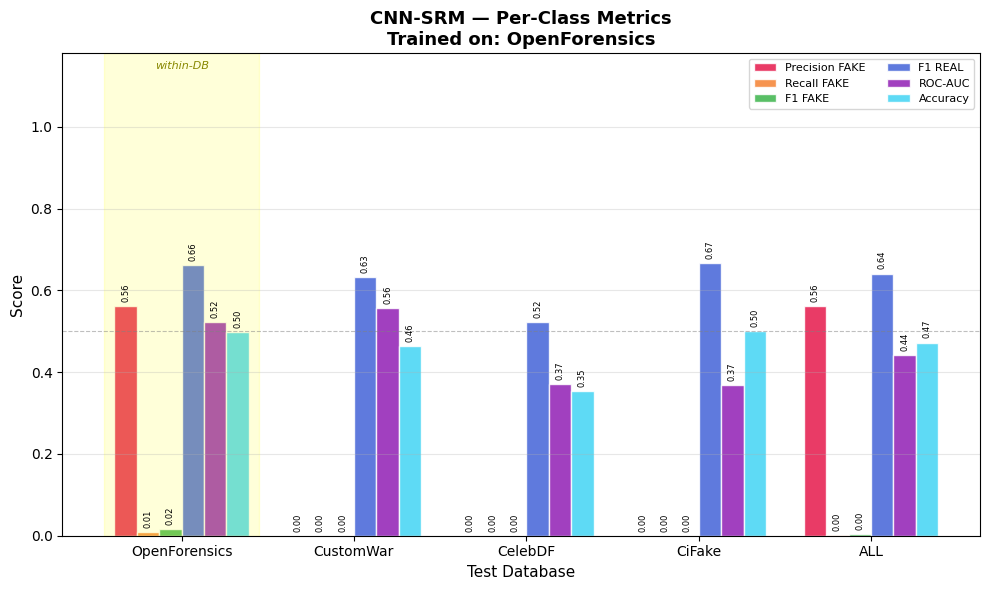

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/cnn_srm/per_class_metrics_OpenForensics.png



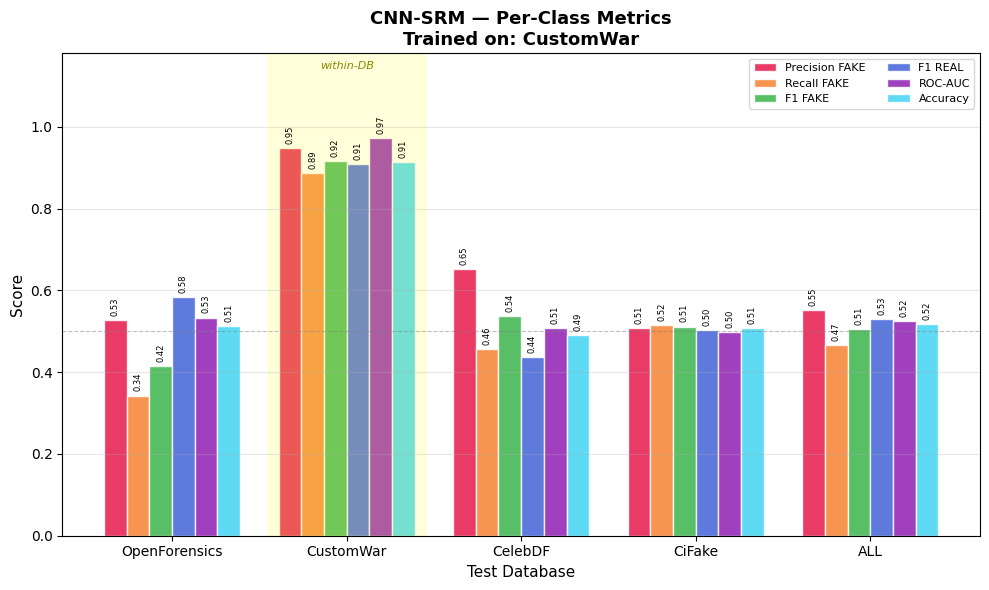

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/cnn_srm/per_class_metrics_CustomWar.png



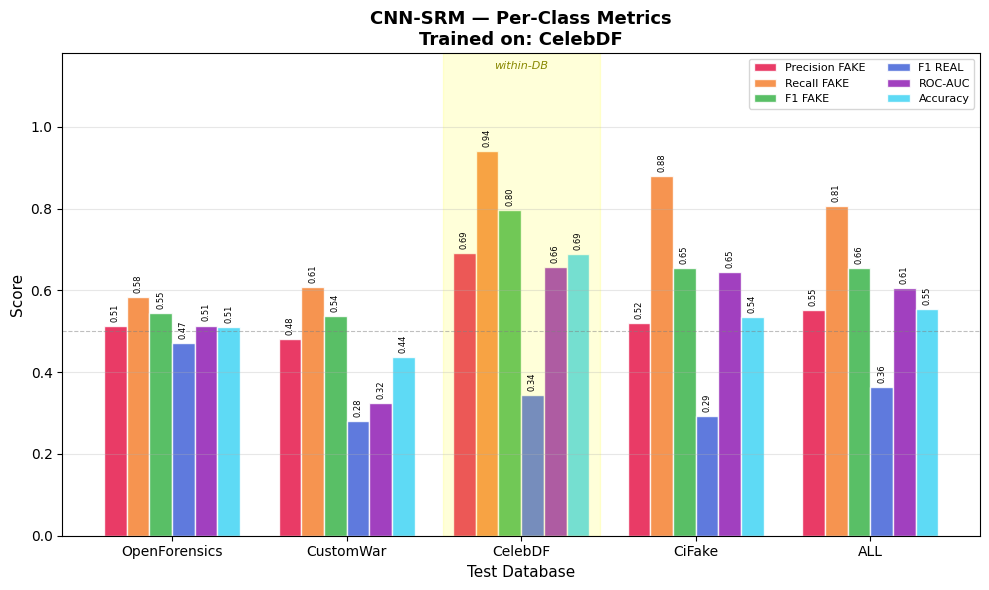

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/cnn_srm/per_class_metrics_CelebDF.png



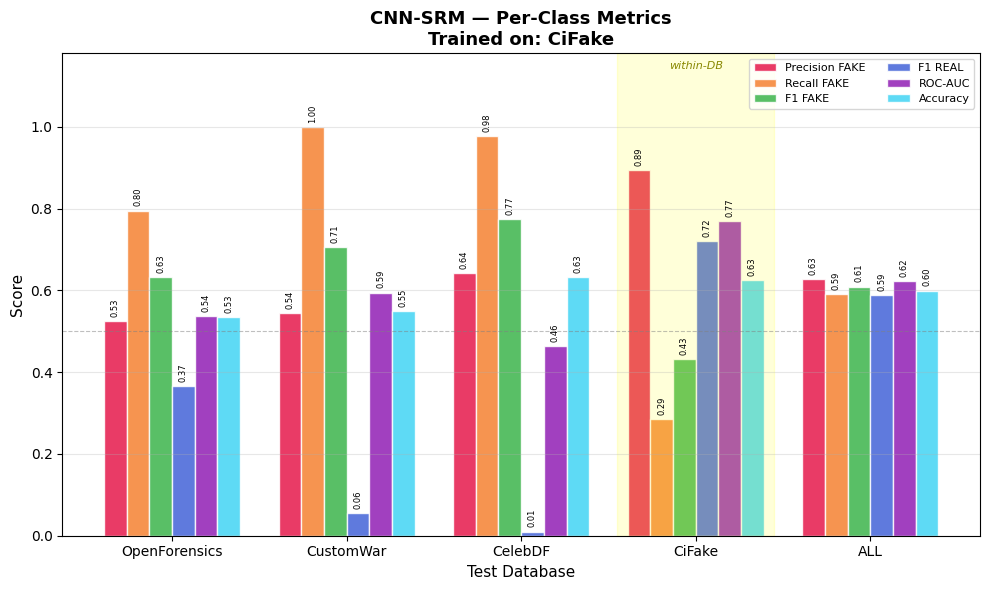

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/cnn_srm/per_class_metrics_CiFake.png



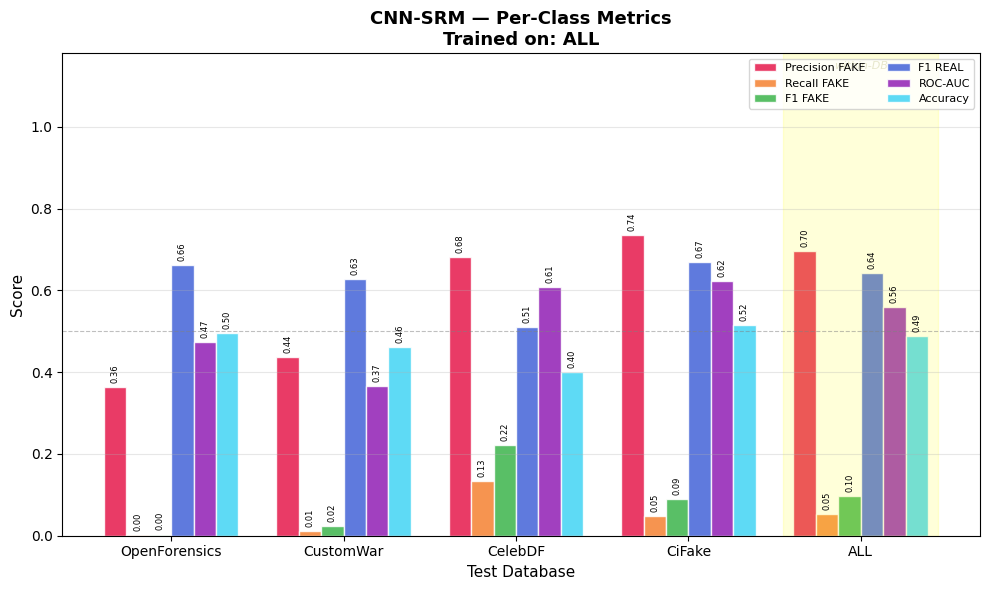

Saved: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/cnn_srm/per_class_metrics_ALL.png



In [15]:
# =================== CELL 14: PER-CLASS METRICS BAR CHART ===================
#
# For each training target: grouped bar chart showing Precision, Recall, F1
# for both REAL and FAKE classes across all 5 test databases.
# Makes it easy to see where a model over-predicts one class.
# ──────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np
import os

axis_names = list(DATABASES.keys()) + ['ALL']

METRICS = [
    ('precision_fake', 'Precision FAKE', '#e6194b'),
    ('recall_fake',    'Recall FAKE',    '#f58231'),
    ('f1_fake',        'F1 FAKE',        '#3cb44b'),
    ('f1_real',        'F1 REAL',        '#4363d8'),
    ('roc_auc',        'ROC-AUC',        '#911eb4'),
    ('accuracy',       'Accuracy',       '#42d4f4'),
]

for train_target in axis_names:
    if train_target not in all_results:
        continue

    test_dbs   = [t for t in axis_names if t in all_results[train_target]]
    n_tests    = len(test_dbs)
    n_metrics  = len(METRICS)
    x          = np.arange(n_tests)
    bar_w      = 0.13
    offsets    = np.linspace(-(n_metrics - 1) / 2, (n_metrics - 1) / 2, n_metrics) * bar_w

    fig, ax = plt.subplots(figsize=(max(10, n_tests * 2), 6))

    for i, (key, label, color) in enumerate(METRICS):
        values = [all_results[train_target][t].get(key, float('nan'))
                  for t in test_dbs]
        bars = ax.bar(x + offsets[i], values, bar_w,
                      label=label, color=color, alpha=0.85, edgecolor='white')
        for bar, val in zip(bars, values):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.01,
                        f'{val:.2f}', ha='center', va='bottom',
                        fontsize=6, rotation=90)

    ax.set_xticks(x)
    ax.set_xticklabels(test_dbs, fontsize=10)
    ax.set_ylim(0, 1.18)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_xlabel('Test Database', fontsize=11)
    ax.set_title(f'CNN-SRM — Per-Class Metrics\nTrained on: {train_target}',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    ax.axhline(0.5, color='gray', lw=0.8, ls='--', alpha=0.5)
    ax.grid(axis='y', alpha=0.3)

    # Highlight within-DB bar group with a shaded background
    if train_target in test_dbs:
        idx = test_dbs.index(train_target)
        ax.axvspan(idx - 0.45, idx + 0.45, color='yellow', alpha=0.15,
                   label='_within-DB')
        ax.text(idx, 1.14, 'within-DB', ha='center', fontsize=8,
                color='#888800', fontstyle='italic')

    plt.tight_layout()
    fig_path = os.path.join(MODEL_DIR, f'per_class_metrics_{train_target}.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig_path}')
    print()

In [16]:
# =================== FINAL GOOGLE DRIVE SYNC ===================
# Syncs ALL models, results (.pkl), CSV, and visualisation PNGs
# to Google Drive.  Runs after visualisations so every PNG is included.
# ────────────────────────────────────────────────────────────────

import subprocess

gdrive_dest  = 'gdrive:deepfake_image_project/models/RealEyes_experiment/cnn_srm'
print(f'Syncing {MODEL_DIR}')
print(f'     to {gdrive_dest} ...')

result = subprocess.run(
    ['rclone', 'sync', MODEL_DIR, gdrive_dest, '--progress', '--stats-one-line'],
    capture_output=False, text=True
)
if result.returncode == 0:
    print(f'\nGoogle Drive sync complete.')
    print(f'  All models, results, and visualisations are now on Drive.')
else:
    print(f'\nWARNING: rclone sync failed (exit {result.returncode}).')
    print(f'  Files are safe locally at {MODEL_DIR}')

Syncing /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/cnn_srm
     to gdrive:deepfake_image_project/models/RealEyes_experiment/cnn_srm ...
608.262 KiB / 1.650 MiB, 36%, 0 B/s, ETA - (xfr#0/14)608.262 KiB / 1.650 MiB, 36%, 608.200 KiB/s, ETA 1s (xfr#0/14)897.268 KiB / 1.650 MiB, 53%, 608.200 KiB/s, ETA 1s (xfr#4/14)897.268 KiB / 1.650 MiB, 53%, 608.200 KiB/s, ETA 1s (xfr#4/14)1.379 MiB / 1.650 MiB, 84%, 448.603 KiB/s, ETA 0s (xfr#8/14)1.379 MiB / 1.650 MiB, 84%, 470.702 KiB/s, ETA 0s (xfr#9/14)1.650 MiB / 1.650 MiB, 100%, 470.702 KiB/s, ETA 0s1.650 MiB / 1.650 MiB, 100%, 422.293 KiB/s, ETA 0s1.650 MiB / 1.650 MiB, 100%, 422.293 KiB/s, ETA 0s

Google Drive sync complete.
  All models, results, and visualisations are now on Drive.


In [17]:
# =================== CELL 12: SAVE RESULTS TABLE ===================

import pandas as pd

rows = []
for train_db, test_map in all_results.items():
    for test_db, metrics in test_map.items():
        rows.append({
            'model':    'cnn_srm',
            'train_db': train_db,
            'test_db':  test_db,
            **metrics,
        })

results_df = pd.DataFrame(rows)
csv_path   = os.path.join(MODEL_DIR, 'cross_db_results.csv')
results_df.to_csv(csv_path, index=False)

print('Results saved to:', csv_path)
print(f'Total rows: {len(results_df)}  (expected 25 for full 5×5)')
display(results_df)

Results saved to: /home/sceuser/RealEyes/gdrive/deepfake_image_project/models/RealEyes_experiment/cnn_srm/cross_db_results.csv
Total rows: 25  (expected 25 for full 5×5)


,model,train_db,test_db,accuracy,roc_auc,f1_fake,f1_real,precision_fake,recall_fake,threshold
0,cnn_srm,OpenForensics,OpenForensics,0.497295,0.522270,0.016152,0.662397,0.562500,0.008194,0.05
1,cnn_srm,OpenForensics,CustomWar,0.462771,0.557566,0.000000,0.632732,0.000000,0.000000,0.05
2,cnn_srm,OpenForensics,CelebDF,0.353891,0.370893,0.000000,0.522776,0.000000,0.000000,0.05
3,cnn_srm,OpenForensics,CiFake,0.500000,0.368785,0.000000,0.666667,0.000000,0.000000,0.05
4,cnn_srm,OpenForensics,ALL,0.472362,0.440848,0.004372,0.641073,0.562500,0.002195,0.05
5,cnn_srm,CustomWar,OpenForensics,0.513618,0.533566,0.415215,0.583673,0.526272,0.342862,0.37
6,cnn_srm,CustomWar,CustomWar,0.913289,0.972848,0.916667,0.909627,0.947566,0.887719,0.37
7,cnn_srm,CustomWar,CelebDF,0.491782,0.508167,0.537586,0.435906,0.652216,0.457226,0.37
8,cnn_srm,CustomWar,CiFake,0.507550,0.497924,0.511531,0.503504,0.507429,0.515700,0.37
9,cnn_srm,CustomWar,ALL,0.517546,0.524469,0.505476,0.529041,0.550750,0.467080,0.37


In [18]:
# =================== CELL 13: TENSORBOARD LAUNCH INSTRUCTIONS ===================

print('-' * 60)
print('  TENSORBOARD DASHBOARD')
print('-' * 60)
print()
print('1. On the SERVER terminal:')
print(f'   tensorboard --logdir {TB_LOG_ROOT} --port 6006 --bind_all')
print()
print('2. On your LOCAL machine, open an SSH tunnel:')
print('   ssh -L 6006:localhost:6006 <your_user>@<server_ip>')
print()
print('3. Open in browser:  http://localhost:6006')
print()
print('TensorBoard log structure for CNN-SRM (now includes ALL run):')
print(f'  {TB_LOG_ROOT}/cnn_srm/')
print('  ├── autoencoder_OpenForensics/   ← AE reconstruction loss')
print('  ├── autoencoder_CustomWar/')
print('  ├── autoencoder_CelebDF/')
print('  ├── autoencoder_CiFake/')
print('  ├── autoencoder_ALL/')
print('  ├── train_OpenForensics/         ← classifier accuracy/AUC')
print('  ├── train_CustomWar/')
print('  ├── train_CelebDF/')
print('  ├── train_CiFake/')
print('  ├── train_ALL/')
print('  └── cross_db_eval/')
print('      ├── train_OpenForensics__test_CustomWar/')
print('      ├── train_OpenForensics__test_ALL/')
print('      ├── train_ALL__test_OpenForensics/')
print('      └── ... (25 train→test pairs)')

------------------------------------------------------------
  TENSORBOARD DASHBOARD
------------------------------------------------------------

1. On the SERVER terminal:
   tensorboard --logdir /home/sceuser/RealEyes/tensorboard_logs --port 6006 --bind_all

2. On your LOCAL machine, open an SSH tunnel:
   ssh -L 6006:localhost:6006 <your_user>@<server_ip>

3. Open in browser:  http://localhost:6006

TensorBoard log structure for CNN-SRM (now includes ALL run):
  /home/sceuser/RealEyes/tensorboard_logs/cnn_srm/
  ├── autoencoder_OpenForensics/   ← AE reconstruction loss
  ├── autoencoder_CustomWar/
  ├── autoencoder_CelebDF/
  ├── autoencoder_CiFake/
  ├── autoencoder_ALL/
  ├── train_OpenForensics/         ← classifier accuracy/AUC
  ├── train_CustomWar/
  ├── train_CelebDF/
  ├── train_CiFake/
  ├── train_ALL/
  └── cross_db_eval/
      ├── train_OpenForensics__test_CustomWar/
      ├── train_OpenForensics__test_ALL/
      ├── train_ALL__test_OpenForensics/
      └── ... (25 train